Mounted at /content/drive
⏳ Veriler Drive'dan Colab yerel diskine kopyalanıyor... (Bu işlem 1-2 dakika sürebilir, lütfen bekle)
✅ Kopyalama işlemi başarıyla tamamlandı!
🚀 Eğitim şu cihaz üzerinde yapılacak: cuda
📁 Bulunan Sınıflar: ['armut', 'elma', 'seftali']
📊 Veri Dağılımı: Eğitim=2461, Doğrulama=527, Test=529

🚀 Eğitim Başlıyor...

Epoch [01/50] | Train Loss: 0.8269 - Acc: 0.6164 | Valid Loss: 0.7420 - Acc: 0.6850
Epoch [02/50] | Train Loss: 0.5307 - Acc: 0.7814 | Valid Loss: 0.4554 - Acc: 0.8083
Epoch [03/50] | Train Loss: 0.3853 - Acc: 0.8513 | Valid Loss: 0.3731 - Acc: 0.8577
Epoch [04/50] | Train Loss: 0.2695 - Acc: 0.8923 | Valid Loss: 0.3520 - Acc: 0.8615
Epoch [05/50] | Train Loss: 0.2084 - Acc: 0.9151 | Valid Loss: 0.2580 - Acc: 0.8956
Epoch [06/50] | Train Loss: 0.1459 - Acc: 0.9451 | Valid Loss: 0.2790 - Acc: 0.9013
Epoch [07/50] | Train Loss: 0.1198 - Acc: 0.9557 | Valid Loss: 0.2869 - Acc: 0.9241
Epoch [08/50] | Train Loss: 0.0960 - Acc: 0.9642 | Valid Loss: 0.2843 - Ac

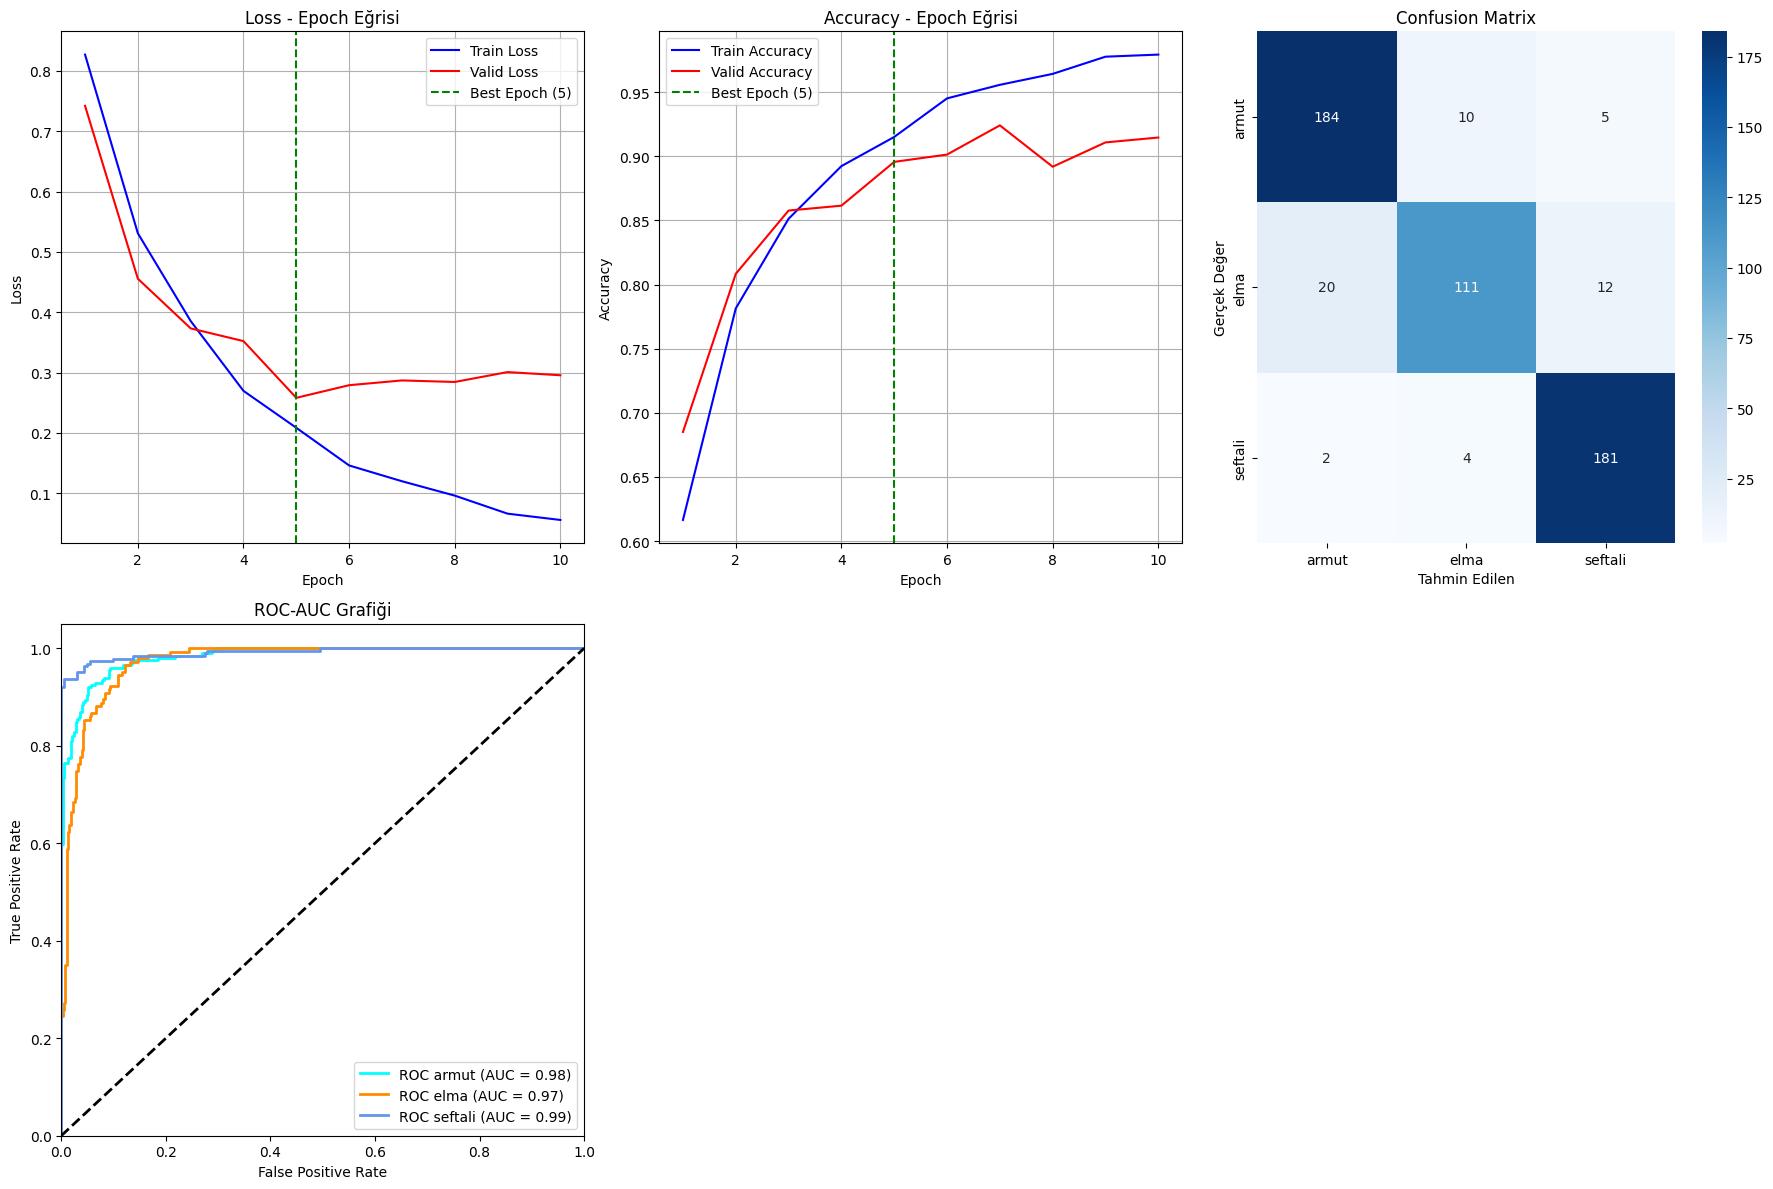

In [1]:
import os
import shutil
from google.colab import drive
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize

# ==========================================
# 0. DRIVE BAĞLANTISI VE VERİ KOPYALAMA (HIZLANDIRICI ADIM)
# ==========================================
drive.mount('/content/drive', force_remount=True)

source_dir = '/content/drive/MyDrive/dataset'
local_dir = '/content/local_dataset'

if not os.path.exists(local_dir):
    print("⏳ Veriler Drive'dan Colab yerel diskine kopyalanıyor... (Bu işlem 1-2 dakika sürebilir, lütfen bekle)")
    try:
        shutil.copytree(source_dir, local_dir)
        print("✅ Kopyalama işlemi başarıyla tamamlandı!")
    except Exception as e:
        print(f"❌ Kopyalama sırasında hata oluştu: {e}")
else:
    print("✅ Veriler zaten yerel diskte mevcut, kopyalama atlandı.")

# ==========================================
# 1. KONFİGÜRASYON (CONFIG) ALANI
# ==========================================
CONFIG = {
    # YENİ YOL: Artık veriyi yerel diskten okuyacak
    'data_dir': local_dir,
    'save_model_path': 'best_fruit_model.pth',

    # Veri Bölme Oranları
    'split_ratios': {'train': 0.70, 'valid': 0.15, 'test': 0.15},

    # Eğitim Hiperparametreleri
    'batch_size': 32,
    'epochs': 50,
    'learning_rate': 0.001,
    'patience': 5, # Early stopping için bekleme süresi
    'weight_decay': 1e-4,

    # Model Mimarisi Parametreleri
    'model_params': {
        'conv1_filters': 32,
        'conv2_filters': 64,
        'conv3_filters': 128,
        'fc1_neurons': 256,
        'dropout_rate': 0.5
    },

    # Donanım ve Sabitler
    'seed': 42,
    'num_classes': 3
}

# Tekrarlanabilirlik için seed ayarı
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])

# Cihaz Seçimi
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Eğitim şu cihaz üzerinde yapılacak: {device}")

# ==========================================
# 2. VERİ HAZIRLIĞI VE BÖLÜNME
# ==========================================
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

try:
    full_dataset = ImageFolder(root=CONFIG['data_dir'], transform=transform)
    class_names = full_dataset.classes
    print(f"📁 Bulunan Sınıflar: {class_names}")
except FileNotFoundError:
    raise Exception(f"HATA: Yerel veri seti bulunamadı. Lütfen kopyalama işleminin başarılı olduğundan emin ol.")

total_size = len(full_dataset)
train_size = int(CONFIG['split_ratios']['train'] * total_size)
valid_size = int(CONFIG['split_ratios']['valid'] * total_size)
test_size = total_size - train_size - valid_size

train_dataset, valid_dataset, test_dataset = random_split(
    full_dataset, [train_size, valid_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=2)

print(f"📊 Veri Dağılımı: Eğitim={len(train_dataset)}, Doğrulama={len(valid_dataset)}, Test={len(test_dataset)}")

# ==========================================
# 3. MODEL MİMARİSİ
# ==========================================
class FruitCNN(nn.Module):
    def __init__(self, config):
        super(FruitCNN, self).__init__()
        p = config['model_params']

        self.conv1 = nn.Conv2d(3, p['conv1_filters'], kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(p['conv1_filters'], p['conv2_filters'], kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(p['conv2_filters'], p['conv3_filters'], kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()

        flatten_size = p['conv3_filters'] * 12 * 12

        self.fc1 = nn.Linear(flatten_size, p['fc1_neurons'])
        self.dropout = nn.Dropout(p['dropout_rate'])
        self.fc2 = nn.Linear(p['fc1_neurons'], config['num_classes'])

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = FruitCNN(CONFIG).to(device)

# ==========================================
# 4. KAYIP FONKSİYONU, OPTİMİZATÖR VE EARLY STOPPING
# ==========================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])

class EarlyStopping:
    def __init__(self, patience=5, path='best_model.pth'):
        self.patience = patience
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.path = path
        self.best_epoch = 0

    def __call__(self, val_loss, model, epoch):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.best_epoch = epoch
        elif val_loss > self.best_loss:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0
            self.best_epoch = epoch

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)

early_stopping = EarlyStopping(patience=CONFIG['patience'], path=CONFIG['save_model_path'])

# ==========================================
# 5. EĞİTİM DÖNGÜSÜ
# ==========================================
history = {'train_loss': [], 'valid_loss': [], 'train_acc': [], 'valid_acc': []}

print("\n🚀 Eğitim Başlıyor...\n")
for epoch in range(CONFIG['epochs']):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = train_loss / train_total
    train_acc = train_correct / train_total

    model.eval()
    valid_loss, valid_correct, valid_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            valid_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            valid_total += labels.size(0)
            valid_correct += (predicted == labels).sum().item()

    valid_loss = valid_loss / valid_total
    valid_acc = valid_correct / valid_total

    history['train_loss'].append(train_loss)
    history['valid_loss'].append(valid_loss)
    history['train_acc'].append(train_acc)
    history['valid_acc'].append(valid_acc)

    print(f"Epoch [{epoch+1:02d}/{CONFIG['epochs']}] | "
          f"Train Loss: {train_loss:.4f} - Acc: {train_acc:.4f} | "
          f"Valid Loss: {valid_loss:.4f} - Acc: {valid_acc:.4f}")

    early_stopping(valid_loss, model, epoch)
    if early_stopping.early_stop:
        print(f"\n🛑 Early Stopping devreye girdi! Eğitim {epoch+1}. epoch'ta durduruldu.")
        break

print(f"\n✅ En iyi model kaydedildi -> {CONFIG['save_model_path']}")

# ==========================================
# 6. TEST VE DEĞERLENDİRME
# ==========================================
model.load_state_dict(torch.load(CONFIG['save_model_path']))
model.eval()

y_true, y_pred, y_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

y_true, y_pred, y_probs = np.array(y_true), np.array(y_pred), np.array(y_probs)

test_acc = accuracy_score(y_true, y_pred)
test_prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
test_rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("\n" + "="*30)
print("🏆 TEST SETİ SONUÇLARI")
print("="*30)
print(f"Accuracy (Doğruluk):  {test_acc:.4f}")
print(f"Precision (Kesinlik): {test_prec:.4f}")
print(f"Recall (Duyarlılık):  {test_rec:.4f}")
print(f"F1 Skoru:             {test_f1:.4f}")
print("="*30)

# ==========================================
# 7. GRAFİKLER VE GÖRSELLEŞTİRME
# ==========================================
best_epoch = early_stopping.best_epoch
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(18, 12))

# 1. Loss Eğrisi
plt.subplot(2, 3, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue')
plt.plot(epochs_range, history['valid_loss'], label='Valid Loss', color='red')
plt.axvline(x=best_epoch + 1, color='g', linestyle='--', label=f'Best Epoch ({best_epoch+1})')
plt.title('Loss - Epoch Eğrisi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. Accuracy Eğrisi
plt.subplot(2, 3, 2)
plt.plot(epochs_range, history['train_acc'], label='Train Accuracy', color='blue')
plt.plot(epochs_range, history['valid_acc'], label='Valid Accuracy', color='red')
plt.axvline(x=best_epoch + 1, color='g', linestyle='--', label=f'Best Epoch ({best_epoch+1})')
plt.title('Accuracy - Epoch Eğrisi')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# 3. Confusion Matrix
plt.subplot(2, 3, 3)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')

# 4. ROC - AUC Curve
plt.subplot(2, 3, 4)
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
n_classes = y_true_bin.shape[1]

fpr, tpr, roc_auc = dict(), dict(), dict()
colors = ['aqua', 'darkorange', 'cornflowerblue']

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'ROC {class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Grafiği')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [ ]:
!cp -r /content/drive/MyDrive/dataset /content/local_dataset
print("✅ Kopyalama işlemi tamamlandı!")

cp: cannot stat '/content/drive/MyDrive/dataset': No such file or directory
✅ Kopyalama işlemi tamamlandı!
